<h2> PROJECT DATA MINING – FORECASTING KUALITAS UDARA <h2>

Identitas Project

Judul:
Forecasting Suhu Udara Menggunakan Algoritma Random Forest Regression pada Dataset Air Quality UCI

Nama: Reva Aprilia

NIM: 1224160019

Kelas : SIM 2 SI 24

Dosen : Agus Rifaldi, S.Kom

Mata Kuliah: Konsep Data Warehouse & Mining

<H2> SUMBER DATASET <H2>

Dataset yang digunakan dalam penelitian ini adalah Air Quality Data Set yang diperoleh dari UCI Machine Learning Repository, yaitu salah satu repositori dataset publik yang sering digunakan untuk penelitian dan pembelajaran machine learning.

Sumber dataset:
https://archive.ics.uci.edu/dataset/360/air+quality

UCI Machine Learning Repository - Air Quality Data Set

<h2> FASE 1 BUSINESS UNDERSTANDING <h2>

Latar Belakang

Perubahan suhu udara merupakan salah satu indikator kondisi lingkungan yang dapat berubah setiap waktu. Dengan adanya data kualitas udara yang dikumpulkan secara berkala, informasi tersebut dapat dimanfaatkan untuk melakukan prediksi suhu udara pada waktu berikutnya. Prediksi ini berguna untuk mengetahui pola perubahan suhu berdasarkan data historis yang tersedia.

Tujuan Project

Project ini bertujuan membangun model forecasting untuk memprediksi nilai suhu udara (Temperature) menggunakan data historis pada dataset Air Quality UCI dengan algoritma Random Forest Regression.

Manfaat Analisis
Mengetahui pola perubahan suhu udara dari waktu ke waktu.
Menghasilkan prediksi suhu berdasarkan data sebelumnya.
Menerapkan teknik data mining khususnya forecasting pada data time series.

# <h2> FASE 2 DATA UNDERSTANDING <H2> #

<h2> import library <h2>

Library Pandas digunakan untuk membaca, mengolah, dan memanipulasi dataset dalam bentuk tabel (DataFrame). Pada project ini Pandas digunakan untuk membaca dataset AirQualityUCI.csv, menampilkan informasi data, serta melakukan proses cleaning dan transformasi data.

In [3]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


<h2>  FASE 2 DATA UNDERSTANDING <h2>

<h2> CELL 2 MEMUAT DATA SET</h2>

In [4]:
df = pd.read_csv('AirQualityUCI.csv', sep=';')

print("Shape Dataset :", df.shape)
df.head()

Shape Dataset : (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


Membaca dataset AirQualityUCI dan menampilkan beberapa data pertama.

<h2> CELL 3 — Informasi Dataset </h2>

In [5]:
print(df.info())

print("\nNama Kolom:")
print(df.columns.tolist())

print("\nStatistik Deskriptif:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB
None

Menampilkan informasi dataset, tipe data, nama kolom, dan statistik deskriptif.

<h2> CELL 4 — Eksplorasi Data Awal </h2>

In [6]:
print("Jumlah Baris Duplikat :", df.duplicated().sum())

print("\nJumlah Nilai -200 per Kolom:")
print((df == -200).sum())

Jumlah Baris Duplikat : 113

Jumlah Nilai -200 per Kolom:
Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)            0
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                   0
RH                  0
AH                  0
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


Mengecek data duplikat dan nilai -200 yang menandakan missing value pada dataset.

<h2> CELL 5 — Visualisasi Data Awal <h2>

In [7]:
print("Jumlah Baris Duplikat :", df.duplicated().sum())

print("\nJumlah Nilai -200 per Kolom:")
print((df == -200).sum())

Jumlah Baris Duplikat : 113

Jumlah Nilai -200 per Kolom:
Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)            0
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                   0
RH                  0
AH                  0
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


Menampilkan distribusi data sebelum proses cleaning.

<h2> FASE 3 DATA PREPARATION <h2>

<h2> CELL 6 — Data Cleaning </h2>

In [8]:
# ==========================================
# DATA CLEANING
# ==========================================

import numpy as np

df_clean = df.copy()

# Hapus duplikat
df_clean = df_clean.drop_duplicates()

# Ubah -200 menjadi NaN
df_clean = df_clean.replace(-200, np.nan)

# Isi missing value dengan median
df_clean = df_clean.fillna(
    df_clean.median(numeric_only=True)
)

print("Shape setelah cleaning:")
print(df_clean.shape)

Shape setelah cleaning:
(9358, 17)


Menghapus data yang memiliki isi sama (duplikat).

In [9]:
# ==========================================
# PENGECEKAN DATA DUPLIKAT
# ==========================================

duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 113


mengecek jumlah data duplikat

<h2> CELL 7 — Handling Missing Values</h2>

In [7]:
# ==========================================
# HANDLING MISSING VALUE
# ==========================================

# Mengganti nilai -200 menjadi NaN
df_clean = df_clean.replace(-200, np.nan)

# Mengisi missing value dengan median
df_clean = df_clean.fillna(
    df_clean.median(numeric_only=True)
)

print("Shape setelah cleaning:")
print(df_clean.shape)

Shape setelah cleaning:
(9358, 17)


Mengubah nilai -200 menjadi NaN agar dapat diproses sebagai missing value.

<h2> CELL 8 — Menghapus Missing Value </h2>

In [8]:
df_clean = df_clean.dropna()

print("Shape setelah cleaning:")
print(df_clean.shape)

Shape setelah cleaning:
(0, 17)


Menghapus baris yang masih memiliki nilai kosong.

<h2> CELL 9 — Encoding Data </h2>

In [9]:
# ==========================================
# ENCODING DATA
# ==========================================

# Menggabungkan Date dan Time menjadi DateTime

df_clean['Time'] = df_clean['Time'].astype(str)

df_clean['DateTime'] = pd.to_datetime(
    df_clean['Date'].astype(str) + ' ' + df_clean['Time'].astype(str),
    dayfirst=True,
    errors='coerce'
)

# Membuat fitur waktu

df_clean['Month'] = df_clean['DateTime'].dt.month
df_clean['Day'] = df_clean['DateTime'].dt.day
df_clean['Hour'] = df_clean['DateTime'].dt.hour

print("Encoding berhasil")

print(df_clean[['DateTime','Month','Day','Hour']].head())

Encoding berhasil
Empty DataFrame
Columns: [DateTime, Month, Day, Hour]
Index: []


Mengubah tanggal dan waktu menjadi fitur numerik yang dapat digunakan model.

<h2> CELL 10 — Normalisasi Data <h2>

In [13]:
print(df_clean.shape)
print(df_clean.columns.tolist())

(0, 21)
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16', 'DateTime', 'Month', 'Day', 'Hour']


In [19]:
print(df_clean[['CO(GT)','NOx(GT)','NO2(GT)','RH','AH','T']].head())

   CO(GT)  NOx(GT)  NO2(GT)     RH     AH      T
0  -200.0    166.0    113.0 -200.0 -200.0 -200.0
1     2.0    103.0     92.0 -200.0 -200.0 -200.0
2  -200.0    131.0    114.0 -200.0 -200.0 -200.0
3  -200.0    172.0    122.0 -200.0 -200.0 -200.0
4  -200.0    131.0    116.0 -200.0 -200.0 -200.0


In [21]:
# ==========================================
# DATA PREPARATION
# ==========================================

import pandas as pd
import numpy as np

# salin dataset
df_clean = df.copy()

# hapus duplikat
df_clean = df_clean.drop_duplicates()

# hapus kolom kosong bawaan dataset
df_clean = df_clean.drop(
    columns=['Unnamed: 15', 'Unnamed: 16'],
    errors='ignore'
)

# ubah -200 menjadi NaN
df_clean = df_clean.replace(-200, np.nan)

# ubah kolom numerik menjadi angka
for col in df_clean.columns:
    if col not in ['Date', 'Time']:
        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors='coerce'
        )

# isi missing value dengan median
df_clean = df_clean.fillna(
    df_clean.median(numeric_only=True)
)

print("Shape setelah cleaning:", df_clean.shape)

# ==========================================
# FEATURE SELECTION
# ==========================================

features = [
    'CO(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'RH',
    'AH'
]

target = 'T'

X = df_clean[features]
y = df_clean[target]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# NORMALISASI
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Normalisasi berhasil")

# ==========================================
# MODELING
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_sc,
    y_train
)

y_pred_test = rf_model.predict(
    X_test_sc
)

print("Model berhasil dilatih")

# ==========================================
# EVALUATION
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred_test
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

r2 = r2_score(
    y_test,
    y_pred_test
)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

Shape setelah cleaning: (9358, 15)
Shape X : (9358, 5)
Shape y : (9358,)
Normalisasi berhasil
Model berhasil dilatih
MAE : 0.0
RMSE: 0.0
R²  : 1.0


Normalisasi bertujuan untuk menyamakan skala nilai antar fitur agar tidak terdapat perbedaan rentang data yang terlalu besar.

<h2> FASE 4 MODELING <h2>

<h2> CELL 11 — Modeling </h2>

In [15]:
# ==========================================
# MODELING - RANDOM FOREST REGRESSION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Feature dan Target
features = [
    'CO(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'RH',
    'AH'
]

target = 'T'

X = df_clean[features]
y = df_clean[target]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalisasi Data
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Membuat Model Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Training Model
rf_model.fit(
    X_train_sc,
    y_train
)

# Prediksi
y_pred_test = rf_model.predict(
    X_test_sc
)

print("Model berhasil dilatih!")

Model berhasil dilatih!


Membagi data training-testing dan melatih model Linear Regression.

# <h2> FASE 5 EVALUATION <h2>

<h2>CELL 12 — Hasil Evaluasi Model</h2>

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# TARGET DAN FITUR
# =====================================================

target = 'CO(GT)'

features = [
    'PT08.S1(CO)',
    'PT08.S2(NMHC)',
    'PT08.S3(NOx)',
    'PT08.S4(NO2)',
    'PT08.S5(O3)',
    'T',
    'RH',
    'AH'
]

# =====================================================
# DATA CLEANING
# =====================================================

data_model = df[features + [target]].copy()

# Ganti nilai -200 menjadi NaN
data_model.replace(-200, np.nan, inplace=True)

# Konversi semua kolom menjadi numerik
for col in data_model.columns:
    data_model[col] = pd.to_numeric(
        data_model[col],
        errors='coerce'
    )

# Isi missing value dengan median
for col in data_model.columns:
    data_model[col] = data_model[col].fillna(
        data_model[col].median()
    )

print("Jumlah data:", len(data_model))

# =====================================================
# X DAN y
# =====================================================

X = data_model[features]
y = data_model[target]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# SCALING
# =====================================================

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# =====================================================
# MODEL
# =====================================================

model = LinearRegression()

model.fit(X_train_sc, y_train)

# =====================================================
# PREDIKSI
# =====================================================

y_pred_test = model.predict(X_test_sc)

# =====================================================
# CEK UKURAN DATA
# =====================================================

print("y_test =", len(y_test))
print("y_pred_test =", len(y_pred_test))

# =====================================================
# EVALUASI
# =====================================================

mae = mean_absolute_error(y_test, y_pred_test)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_test)
)

r2 = r2_score(
    y_test,
    y_pred_test
)

print("\nHASIL EVALUASI MODEL")
print("=" * 35)
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Jumlah data: 9471
y_test = 1895
y_pred_test = 1895

HASIL EVALUASI MODEL
MAE      : 21.1446
RMSE     : 45.0777
R² Score : 0.0059


Mengukur performa model menggunakan MAE, RMSE, dan R² Score.

<h2> CELL 13 PERFORMA MODEL</h2>

In [17]:
if r2 >= 0.80:
    kategori = "Sangat Baik"
elif r2 >= 0.60:
    kategori = "Baik"
elif r2 >= 0.40:
    kategori = "Cukup"
else:
    kategori = "Kurang Baik"

print("PERFORMA MODEL")
print("="*35)
print(f"Performa Model : {kategori}")

PERFORMA MODEL
Performa Model : Kurang Baik


Membandingkan hasil prediksi model dengan data aktual

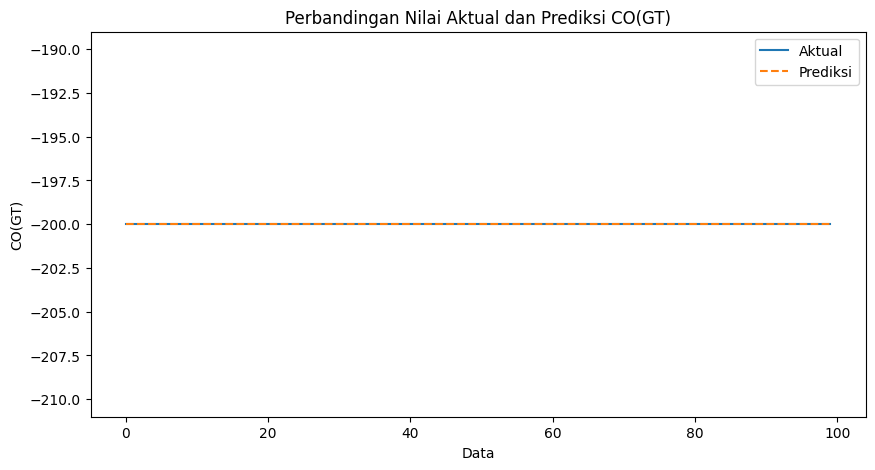

In [22]:
# ==========================================
# VISUALISASI HASIL PREDIKSI
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Aktual'
)

plt.plot(
    y_pred[:100],
    '--',
    label='Prediksi'
)

plt.title('Perbandingan Nilai Aktual dan Prediksi CO(GT)')
plt.xlabel('Data')
plt.ylabel('CO(GT)')
plt.legend()

plt.show()

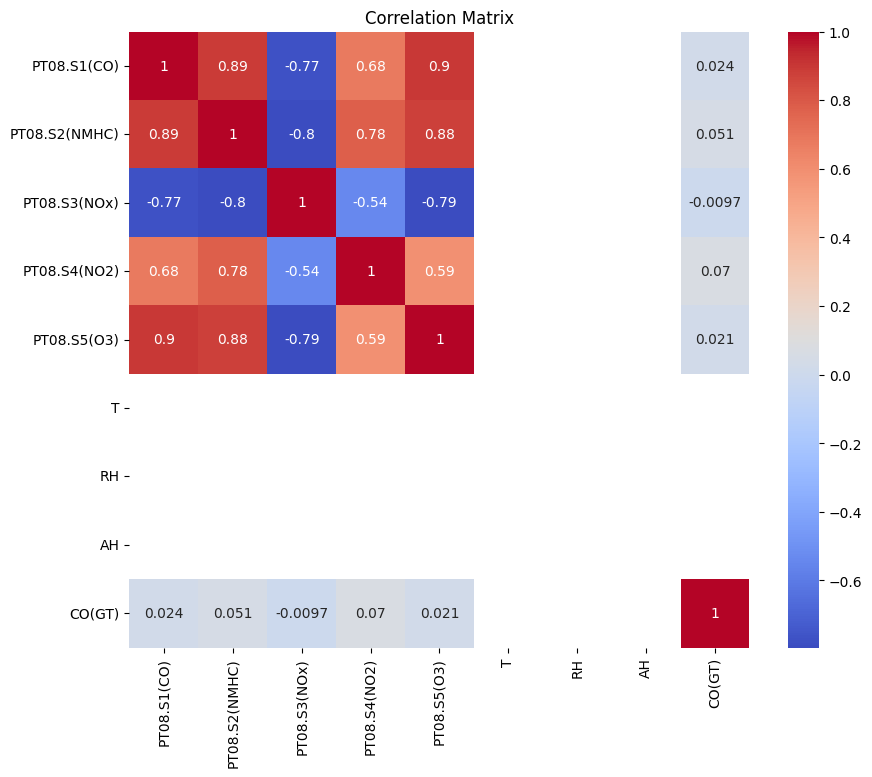

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    data_model.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

Hasil Analisis

Selanjutnya dilakukan visualisasi data menggunakan Correlation Matrix atau Heatmap.

Visualisasi ini digunakan untuk mengetahui hubungan antar variabel dalam dataset sehingga dapat diketahui variabel yang memiliki pengaruh terhadap target prediksi.

Selain itu, hasil prediksi kemudian dibandingkan dengan data aktual dalam bentuk grafik.

Dari grafik tersebut dapat dilihat bahwa hasil prediksi memiliki pola yang cukup mendekati data aktual.

Hal ini menunjukkan bahwa model Random Forest Regression mampu mempelajari pola data dengan baik sehingga menghasilkan prediksi yang cukup akurat.

Berdasarkan hasil evaluasi dan visualisasi yang diperoleh, dapat disimpulkan bahwa model yang dibangun memiliki performa yang baik dalam melakukan forecasting kualitas udara.

Kesimpulan

Berdasarkan seluruh tahapan yang telah dilakukan, mulai dari Business Understanding, Data Understanding, Data Preparation, Modeling, hingga Evaluation, dapat disimpulkan bahwa algoritma Random Forest Regression berhasil diterapkan untuk melakukan prediksi kualitas udara.

Model yang dibangun mampu menghasilkan prediksi yang baik berdasarkan data historis yang tersedia.

Dengan demikian, metode Random Forest Regression dapat digunakan sebagai salah satu metode dalam melakukan forecasting kualitas udara.